In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q, day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [4]:
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/dic_vert_doppio.pkl')


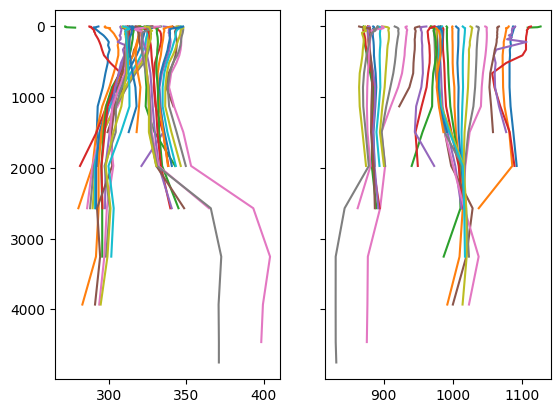

In [27]:
eddy = 3800

dic = dic_vert[f'Eddy{eddy}']
fig, axs = plt.subplots(1, 2, sharey=True)
for day in dic.keys():
    df = dic[day].copy()
    axs[0].plot(df.xc, df.Depth.abs())
    axs[1].plot(df.yc, df.Depth.abs())
axs[0].invert_yaxis()



In [20]:
df_eddies[df_eddies.Eddy==3100]

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
127631,3100,8833,CE,158.776258,-38.387915,268,73,969.020910,360.839001,-0.000012,...,0.995056,-0.023867,1.056325,48.992948,4.167387,1.038607,31.492082,23,2014-03-09,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127632,3100,8834,CE,158.779371,-38.432156,268,72,970.456945,356.199733,-0.000011,...,0.877764,0.008680,1.225296,48.992948,4.167387,1.181745,27.276961,23,2014-03-10,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127633,3100,8835,CE,158.793653,-38.466330,268,72,972.573477,352.977994,-0.000008,...,0.803181,-0.093745,1.300695,48.992948,4.167387,1.294734,32.811512,23,2014-03-11,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127634,3100,8836,CE,158.772763,-38.585930,269,69,973.957206,339.539896,-0.000007,...,0.755170,-0.050437,1.365888,48.992948,4.167387,1.350625,31.783400,23,2014-03-12,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127635,3100,8837,CE,158.773906,-38.553263,269,70,973.192735,343.071469,-0.000009,...,0.732360,-0.128103,1.485162,48.992948,4.167387,1.455398,32.277043,23,2014-03-13,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127636,3100,8838,CE,158.775057,-38.520596,268,70,972.428264,346.603042,-0.000010,...,0.709549,-0.205768,1.604435,48.992948,4.167387,1.575525,32.770687,23,2014-03-14,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127637,3100,8839,CE,158.814341,-38.562848,269,70,976.875402,343.277167,-0.000006,...,0.637919,-0.393696,1.960460,48.992948,4.167387,1.976448,30.335854,23,2014-03-15,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127638,3100,8840,CE,158.800254,-38.685745,269,67,978.912840,329.690195,-0.000005,...,0.704082,-0.425331,1.866679,48.992948,4.167387,1.883952,33.314520,23,2014-03-16,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127639,3100,8841,CE,158.740935,-38.678131,269,67,973.688436,328.701197,-0.000007,...,0.777006,-0.384044,1.667132,48.992948,4.167387,1.689317,32.178602,23,2014-03-17,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
127640,3100,8842,CE,158.681615,-38.670516,268,66,968.464033,327.712200,-0.000008,...,0.849930,-0.342756,1.467585,48.992948,4.167387,1.524174,31.042683,23,2014-03-18,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
